# Assignment 3 — Image Collection & Basic Processing

**Goal:** Download images → Organise into folders → Explore dataset → Convert to NumPy arrays → Build a DataFrame

**Categories chosen:** Cats | Dogs | Birds

---

In [22]:
!pip install icrawler Pillow 

---
# PART 1 — Download Images

We use `icrawler` (a Python-based image crawling library) to automatically download images from Google Image Search.

**Strategy:**
- Download **100 images** per category to ensure at least **50 valid images** after removing corrupt/bad files.
- Images are saved directly into organised subfolders under `data/raw/`.

## Step 1 — Import Libraries

In [23]:
import os                          
import random                  
import numpy as np                 
import pandas as pd                
import matplotlib.pyplot as plt    
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from PIL import Image              
from icrawler.builtin import GoogleImageCrawler 

## Step 2 — Define Folder Structure & Categories

In [24]:
CATEGORIES = ['cats', 'dogs', 'birds']
BASE_DIR = './data/raw'

for category in CATEGORIES:
    folder_path = os.path.join(BASE_DIR, category)  
    os.makedirs(folder_path, exist_ok=True)

## Step 3 — Download Images Using `icrawler`

In [25]:
import time

MAX_IMAGES = 100

for category in CATEGORIES:
    save_path = os.path.join(BASE_DIR, category)
    os.makedirs(save_path, exist_ok=True)

    print(f"\nDownloading images for: {category}")

    crawler = GoogleImageCrawler(
        storage={'root_dir': save_path},
        log_level=50,
        downloader_threads=1,
        parser_threads=1
    )

    try:
        crawler.crawl(keyword=category, max_num=MAX_IMAGES)
    except Exception as e:
        print(f"Error: {e}")

    time.sleep(2) 

    downloaded = len(os.listdir(save_path))
    print(f"Downloaded {downloaded} images")

Exception in thread parser-001:
Traceback (most recent call last):
  File "C:\Users\Raja\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Raja\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Raja\anaconda3\Lib\site-packages\icrawler\parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Downloaded 57 images



Exception in thread parser-001:
Traceback (most recent call last):
  File "C:\Users\Raja\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Raja\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Raja\anaconda3\Lib\site-packages\icrawler\parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Downloaded 62 images



Exception in thread parser-001:
Traceback (most recent call last):
  File "C:\Users\Raja\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Raja\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Raja\anaconda3\Lib\site-packages\icrawler\parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Downloaded 45 images


> **Output Insight:** `icrawler` searches Google Images for each keyword and saves files as numbered JPEGs (`000001.jpg`, `000002.jpg`, ...). Network speed affects download time. Expect **2-5 minutes** per category.
>
> **Note:** Google may occasionally block requests — if a category shows fewer downloads than expected, simply re-run that cell.

## Step 4 — Verify Download Count

In [26]:
for category in CATEGORIES:
    
    folder = os.path.join(BASE_DIR, category)

    count = len(os.listdir(folder))

    print(f"{category}: {count} images")

cats: 57 images
dogs: 62 images
birds: 45 images


---
# Part 2 — Explore Dataset 

## Step 1: Count Images

In [27]:
for category in CATEGORIES:
    
    folder = os.path.join(BASE_DIR, category)

    images = os.listdir(folder)

    print(f"{category}: {len(images)}")

cats: 57
dogs: 62
birds: 45


## Step 2: Remove Bad Files

In [28]:
for category in CATEGORIES:

    folder = os.path.join(BASE_DIR, category)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        try:
            img = Image.open(path)
            img.verify()

            # Check empty file
            if os.path.getsize(path) == 0:
                os.remove(path)

        except:
            os.remove(path)

print("Bad files removed")

Bad files removed


## Step 3: Display Sample Images

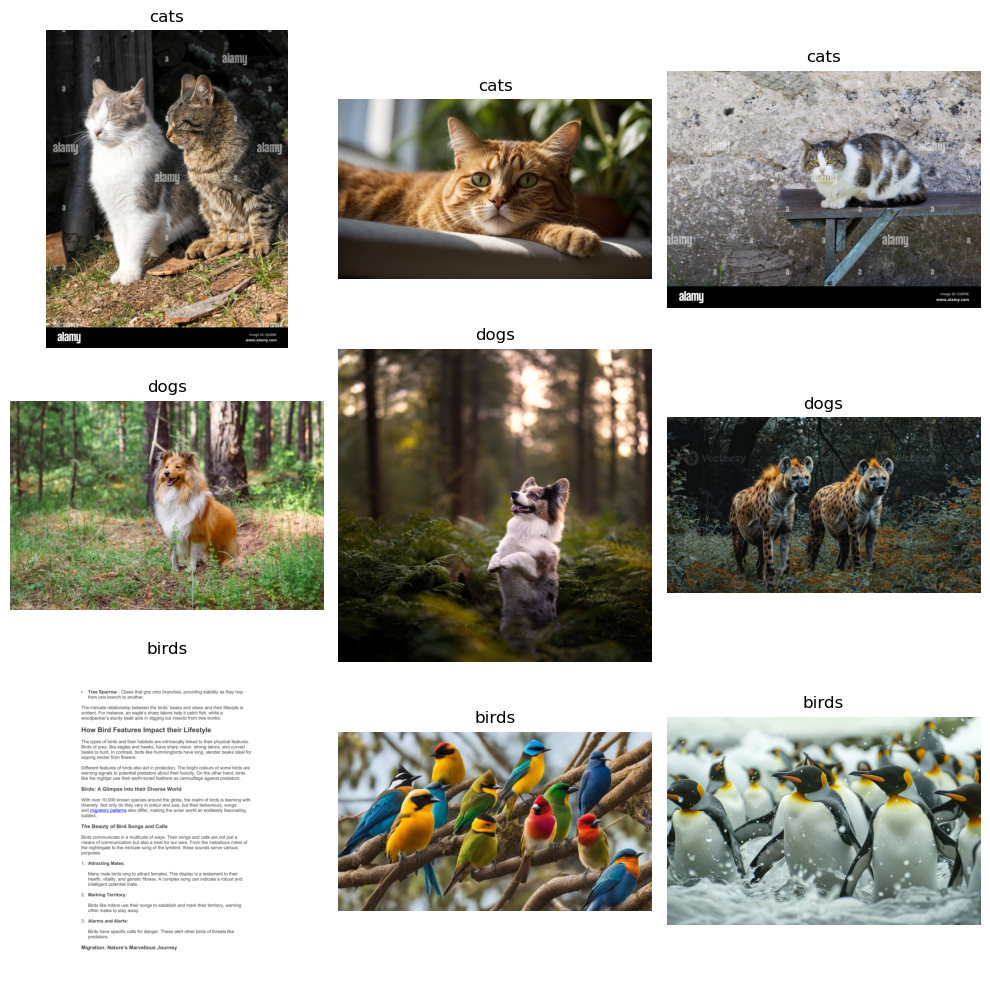

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for row, category in enumerate(CATEGORIES):

    folder = os.path.join(BASE_DIR, category)

    images = random.sample(os.listdir(folder), 3)

    for col, image_name in enumerate(images):

        path = os.path.join(folder, image_name)

        img = Image.open(path)

        axes[row, col].imshow(img)
        axes[row, col].set_title(category)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Step 4: Check Image Properties

In [30]:
all_images = []

for category in CATEGORIES:

    folder = os.path.join(BASE_DIR, category)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        all_images.append(path)

In [31]:
sample_images = random.sample(all_images, 5)

for path in sample_images:

    img = Image.open(path)

    img_array = np.array(img)

    print("Path:", path)
    print("Width:", img.width)
    print("Height:", img.height)

    if len(img_array.shape) == 3:
        print("Channels:", img_array.shape[2])
    else:
        print("Channels: 1")

    print("-" * 40)

Path: ./data/raw\dogs\000052.jpg
Width: 1300
Height: 956
Channels: 3
----------------------------------------
Path: ./data/raw\cats\000039.jpg
Width: 1300
Height: 956
Channels: 3
----------------------------------------
Path: ./data/raw\birds\000032.jpg
Width: 1200
Height: 838
Channels: 3
----------------------------------------
Path: ./data/raw\dogs\000058.jpg
Width: 1024
Height: 532
Channels: 3
----------------------------------------
Path: ./data/raw\cats\000045.jpg
Width: 1344
Height: 896
Channels: 3
----------------------------------------


## Step 5: Check Image Type

In [32]:
mode_counts = {
    'RGB': 0,
    'RGBA': 0,
    'L': 0
}

for category in CATEGORIES:

    folder = os.path.join(BASE_DIR, category)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        try:
            img = Image.open(path)

            mode = img.mode

            if mode in mode_counts:
                mode_counts[mode] += 1

        except:
            pass
            
print(mode_counts)

{'RGB': 164, 'RGBA': 0, 'L': 0}


---
# Part 3 - Final Task — Create DataFrame

## Step 1: Load Images
## Step 2: Convert to NumPy
## Step 3: Flatten Image
## Step 4: Create Data List

In [33]:
data = []
labels = []
for category in CATEGORIES:

    folder = os.path.join(BASE_DIR, category)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        try:
            # Open image
            img = Image.open(path)

            # Convert to RGB
            img = img.convert('RGB')

            # Resize image
            img = img.resize((128, 128))

            # Convert to NumPy
            img_array = np.array(img)

            # Flatten image
            flat_img = img_array.flatten()

            # Store data
            data.append(flat_img)

            # Store label
            labels.append(category)

        except:
            pass


## Step 5: Create DataFrame


In [34]:
df = pd.DataFrame({
    'image': data,
    'label': labels
})

In [35]:
df

,image,label
0,"[178, 111, 68, 97, 75, 61, 100, 80, 70, 122, 7...",cats
1,"[223, 228, 232, 226, 228, 231, 228, 229, 231, ...",cats
2,"[249, 252, 250, 240, 241, 247, 220, 228, 231, ...",cats
3,"[26, 24, 25, 27, 25, 26, 27, 25, 26, 28, 26, 2...",cats
4,"[236, 233, 230, 215, 218, 221, 223, 230, 235, ...",cats
...,...,...
159,"[183, 177, 161, 173, 157, 134, 126, 111, 90, 9...",birds
160,"[11, 18, 26, 11, 18, 26, 12, 19, 27, 12, 19, 2...",birds
161,"[238, 147, 66, 243, 150, 66, 174, 113, 60, 28,...",birds
162,"[186, 172, 146, 188, 173, 147, 190, 175, 148, ...",birds


---
# Final Information

In [36]:
print("Total Rows:", len(df))

Total Rows: 164


In [37]:
print(df['label'].value_counts())

label
dogs     62
cats     57
birds    45
Name: count, dtype: int64


---
# Conclusion
- Collected and organised image datasets for different categories.
- Cleaned and validated images by removing corrupted files.
- Analysed image properties like size, format, and color modes.
- Converted images into numerical data for machine learning.
- Prepared a structured dataset for future image classification projects.
